In [6]:
# 1. LIBRERÍAS Y CONFIGURACIÓN
import pandas as pd
import joblib
from pathlib import Path
import matplotlib.pyplot as plt

# Rutas principales (Ajusta la ruta base según tu entorno)
ruta_modelos = Path(r"D:\ProyectoAnalisisElectrico\Modelos\ModeloSegmentacion")
ruta_nolocs = Path(r"D:\ProyectoAnalisisElectrico\BarrasEstaciones\infraestructura_nolocalizada.parquet")

# AQUÍ APUNTAMOS A LA BASE MAESTRA DE CMG
ruta_cmg_raw = Path(r"D:\ProyectoAnalisisElectrico\Cmg\Cmg_period.parquet")

In [2]:
# A. Cargar el Cerebro (Modelo, Encoder y Referencia)
print("Cargando artefactos del modelo...")
rf_model = joblib.load(ruta_modelos / 'rf_model_energia_d6_full.joblib')
le = joblib.load(ruta_modelos / 'label_encoder_energia_d6_full.joblib')
ref_sistema = joblib.load(ruta_modelos / 'valor_referencia_full.joblib')

# B. Cargar la lista de barras a predecir
df_nolocs = pd.read_parquet(ruta_nolocs)
print(f"Total de barras sin ubicación a predecir: {len(df_nolocs)}")

# C. Cargar historial de CMg (Base Maestra)
print("Cargando base histórica maestra de CMg (esto puede tomar unos segundos)...")
df_cmg_raw = pd.read_parquet(ruta_cmg_raw)

# Filtrar INMEDIATAMENTE la base pesada para quedarnos solo con las barras que nos interesan
df_target_raw = df_cmg_raw[df_cmg_raw['nombre_barra_cmg'].isin(df_nolocs['nombre_barra_cmg'])]

# D. Estandarizar nombres de columnas para el Feature Engineering
df_target = pd.DataFrame()
df_target['name'] = df_target_raw['nombre_barra_cmg']
df_target['hora'] = df_target_raw['HORA'].astype(int)

# Extraemos el costo marginal en dólares, tal como fue entrenado el modelo
df_target['cmg'] = pd.to_numeric(df_target_raw['CMg[USD/MWh]']) 
df_target['mes'] = df_target_raw['Mes'].astype(int)


Cargando artefactos del modelo...
Total de barras sin ubicación a predecir: 314
Cargando base histórica maestra de CMg (esto puede tomar unos segundos)...


In [3]:
# a) Rampas
df_ord = df_target.sort_values(['name', 'mes', 'hora'])
df_ord['Rampa'] = df_ord.groupby('name')['cmg'].diff()
df_rampas = df_ord.groupby('name').agg(
    rampa_max_subida=('Rampa', 'max'),
    rampa_max_bajada=('Rampa', 'min')
).reset_index()

# b) Perfil 24 Horas
df_24h = df_target.groupby(["name", "hora"])["cmg"].mean().reset_index()
df_24h_pivot = df_24h.pivot(index="name", columns="hora", values="cmg").reset_index()
df_24h_pivot.columns = ["name"] + [f"hora_{int(h)}" for h in df_24h_pivot.columns[1:]]

# c) Perfil 12 Meses
df_mes = df_target.groupby(["name", "mes"])["cmg"].mean().reset_index()
df_mes_pivot = df_mes.pivot(index="name", columns="mes", values="cmg").reset_index()
df_mes_pivot.columns = ["name"] + [f"mes_{int(m)}" for m in df_mes_pivot.columns[1:]]

# d) Consolidar Matriz
df_base = pd.DataFrame({'name': df_target['name'].unique()})
df_features = pd.merge(df_base, df_rampas, on="name", how="left")
df_features = pd.merge(df_features, df_24h_pivot, on="name", how="left")
df_features = pd.merge(df_features, df_mes_pivot, on="name", how="left")

# e) Alinear Columnas exactas que usó el modelo 
X_predict = df_features.drop(columns=['name'])
# El reindex asegura que todas las columnas (hora_1 a hora_24, mes_1 a mes_12) existan
# para que la función procesar_features no falle
X_predict = X_predict.reindex(columns=rf_model.feature_names_in_, fill_value=0)

print(f"Matriz de predicción lista: {X_predict.shape[0]} barras, {X_predict.shape[1]} variables.")

Matriz de predicción lista: 314 barras, 40 variables.


In [4]:
# Función de normalización
def procesar_features(df_in, valor_referencia):
    df_out = df_in.copy()
    cols_horas = [f"hora_{i}" for i in range(1, 25)]
    cols_meses = [f"mes_{i}" for i in range(1, 13)]
    cols_rampas = ['rampa_max_subida', 'rampa_max_bajada']
    
    # Calcular máximo por barra para estandarizar
    max_por_barra = df_out[cols_horas].max(axis=1).replace(0, 1)
    
    # Normalización de magnitud relativa al sistema
    df_out['factor_magnitud'] = max_por_barra / valor_referencia
    
    for col in cols_horas + cols_meses + cols_rampas:
        df_out[col] = df_out[col] / max_por_barra
        
    return df_out.fillna(-1), valor_referencia

# 1. Normalizar usando la referencia del sistema guardada
X_predict_norm, _ = procesar_features(X_predict, valor_referencia=ref_sistema)

# 2. PREDICCIÓN
predicciones_num = rf_model.predict(X_predict_norm)
probabilidades = rf_model.predict_proba(X_predict_norm) 

# 3. Decodificar e interpretar
predicciones_texto = le.inverse_transform(predicciones_num)
confianza = probabilidades.max(axis=1) * 100

# Anexar resultados al dataframe de features
df_features['Macrozona_Predicha'] = predicciones_texto
df_features['Confianza_IA_%'] = confianza.round(2)

print("¡IA aplicada! Predicciones calculadas con éxito.")

¡IA aplicada! Predicciones calculadas con éxito.


--- Resumen Estadístico de la Confianza ---
count    314.00
mean      91.94
std       11.25
min       34.87
25%       91.60
50%       95.21
75%       98.70
max       99.99
Name: Confianza_IA_%, dtype: float64

Barras con ALTA confianza (>= 80.0%): 275 (87.6%)
Barras dudosas (< 80.0%): 39 (12.4%)


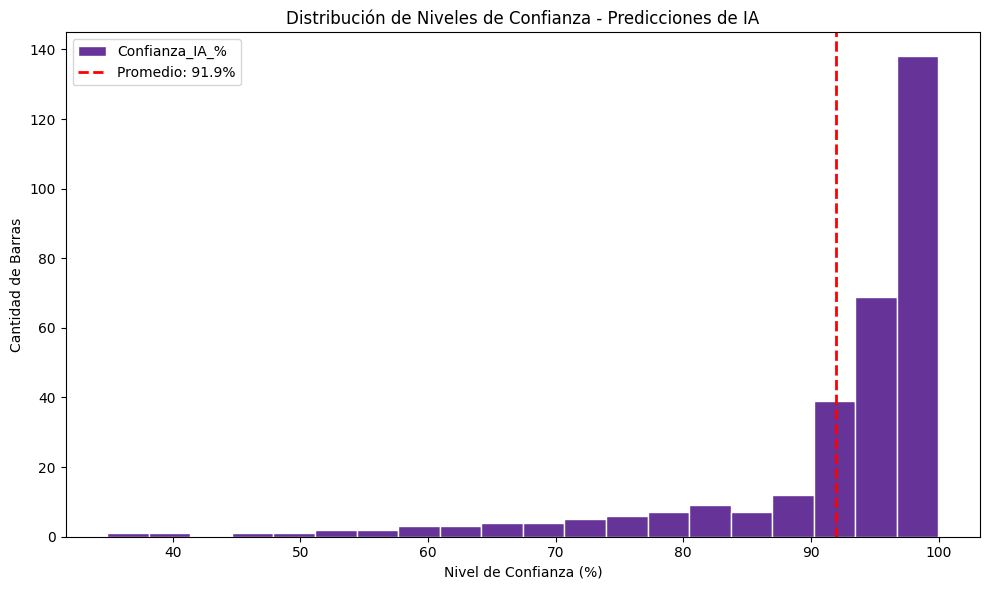

,nombre_barra,nombre_barra_cmg,tension,Macrozona_Predicha,Confianza_IA_%
0,TOESTE,TOESTE________220,220,Norte Grande,93.74
1,VERBENAS,VERBENAS______220,220,Norte Chico,99.99
2,TAPTALTAL1,TAPTALTAL1____220,220,Norte Grande,79.91
3,CALDERA,CALDERA_______110,110,Norte Chico,94.66
4,A.MELIP,A.MELIP_______220,220,Centro,97.97


In [12]:
# Unir las predicciones con el dataframe original
df_final = pd.merge(
    df_nolocs, 
    df_features[['name', 'Macrozona_Predicha', 'Confianza_IA_%']], 
    left_on='nombre_barra_cmg', 
    right_on='name', 
    how='left'
).drop(columns=['name'])
ruta_exportacion = Path(r"D:\ProyectoAnalisisElectrico\BarrasEstaciones\infraestructura_recuperada_IA.parquet")
df_final.to_parquet(ruta_exportacion, engine="pyarrow", compression="snappy")

# 1. Resumen Estadístico Básico
print("--- Resumen Estadístico de la Confianza ---")
print(df_final['Confianza_IA_%'].describe().round(2))

# 2. Análisis por Umbrales (Ejemplo: corte al 80%)
umbral = 80.0
alta_confianza = df_final[df_final['Confianza_IA_%'] >= umbral]
baja_confianza = df_final[df_final['Confianza_IA_%'] < umbral]

print(f"\nBarras con ALTA confianza (>= {umbral}%): {len(alta_confianza)} ({(len(alta_confianza)/len(df_final))*100:.1f}%)")
print(f"Barras dudosas (< {umbral}%): {len(baja_confianza)} ({(len(baja_confianza)/len(df_final))*100:.1f}%)")

# 3. Visualización de la Distribución (Histograma con Matplotlib/Pandas)
plt.figure(figsize=(10, 6))

# Usamos la función hist integrada en pandas (que usa matplotlib por debajo)
df_final['Confianza_IA_%'].plot(kind='hist', bins=20, color='rebeccapurple', edgecolor='white')
# Línea marcando el promedio
promedio = df_final['Confianza_IA_%'].mean()
plt.axvline(promedio, color='red', linestyle='dashed', linewidth=2, label=f"Promedio: {promedio:.1f}%")

plt.title('Distribución de Niveles de Confianza - Predicciones de IA')
plt.xlabel('Nivel de Confianza (%)')
plt.ylabel('Cantidad de Barras')
plt.legend()
plt.tight_layout()
plt.show()
df_final.head()

In [14]:
# 1. Definir la ruta base
base_dir = Path(r"D:\ProyectoAnalisisElectrico\BarrasEstaciones")

# 2. Cargar SOLO el dataset de las localizadas (el de IA ya lo tenemos en la variable 'df_final')
print("Cargando archivo de barras oficiales localizadas...")
df_locs = pd.read_parquet(base_dir / "infraestructura_localizada.parquet")

# 3. Preparar el dataset de Localizadas (Oficiales)
# Agregamos 'Provincia' a la lista de columnas extraídas
df_locs_clean = df_locs[['nombre_barra', 'nombre_barra_cmg', 'tension', 'Macrozona', 'Región', 'Provincia']].copy()
df_locs_clean = df_locs_clean.rename(columns={
    'Macrozona': 'macrozona', 
    'Región': 'region',
    'Provincia': 'provincia'
})
df_locs_clean['confianza'] = 100.0   # 100% de confianza porque es dato oficial
df_locs_clean['IA'] = False          # No fue procesado por IA

# 4. Preparar el dataset de Recuperadas usando tu variable en memoria (df_final)
df_ia_clean = df_final[['nombre_barra', 'nombre_barra_cmg', 'tension', 'Macrozona_Predicha', 'Confianza_IA_%']].copy()
df_ia_clean = df_ia_clean.rename(columns={
    'Macrozona_Predicha': 'macrozona', 
    'Confianza_IA_%': 'confianza'
})
df_ia_clean['region'] = None         # Las dejamos vacías como solicitaste
df_ia_clean['provincia'] = None      # Dejamos la provincia vacía para las IA
df_ia_clean['IA'] = True             # Sí fue procesado por IA

# 5. Unir ambos mundos en un solo DataFrame
df_consolidado = pd.concat([df_locs_clean, df_ia_clean], ignore_index=True)

# 6. Ordenar las columnas para que quede exactamente como pediste
columnas_finales = [
    'nombre_barra', 
    'nombre_barra_cmg', 
    'tension', 
    'region', 
    'provincia',
    'macrozona', 
    'confianza', 
    'IA'
]
df_consolidado = df_consolidado[columnas_finales]

# Mostrar un resumen
print("\n--- RESUMEN DE INFRAESTRUCTURA CONSOLIDADA ---")
print(f"Total de barras en el sistema: {len(df_consolidado)}")
print(f"Barras Oficiales (IA=False): {len(df_consolidado[df_consolidado['IA'] == False])}")
print(f"Barras Recuperadas (IA=True): {len(df_consolidado[df_consolidado['IA'] == True])}")

# 7. Exportar el archivo maestro
ruta_salida = base_dir / "infraestructura_consolidada.parquet"
df_consolidado.to_parquet(ruta_salida, engine="pyarrow", compression="snappy")

print(f"\nArchivo maestro guardado exitosamente en:\n{ruta_salida}")

Cargando archivo de barras oficiales localizadas...

--- RESUMEN DE INFRAESTRUCTURA CONSOLIDADA ---
Total de barras en el sistema: 1420
Barras Oficiales (IA=False): 1106
Barras Recuperadas (IA=True): 314

Archivo maestro guardado exitosamente en:
D:\ProyectoAnalisisElectrico\BarrasEstaciones\infraestructura_consolidada.parquet


In [15]:
df_consolidado.head()

,nombre_barra,nombre_barra_cmg,tension,region,provincia,macrozona,confianza,IA
0,ALHUE,ALHUE_________066,66,Metropolitana de Santiago,Melipilla,Centro,100.0,False
1,E.PENON,E.PENON_______066,66,Coquimbo,Elqui,Norte Chico,100.0,False
2,ANDACOLLO,ANDACOLLO_____066,66,Coquimbo,Elqui,Norte Chico,100.0,False
3,ANDACOLLO,ANDACOLLO_____013,13,Coquimbo,Elqui,Norte Chico,100.0,False
4,FUTURO,FUTURO________033,33,Antofagasta,Antofagasta,Norte Grande,100.0,False
